# Notebook 03: Gauge Fields and Plaquettes

**Learning objectives:**
- Understand gauge links as SU(2) matrices living on lattice edges
- Compute the plaquette -- the smallest Wilson loop
- Relate plaquettes to the Wilson gauge action
- Compare cold start ($\langle P \rangle = 1$) and hot start ($\langle P \rangle \approx 0$)
- Compute staples (the "environment" of a single link)

**Prerequisites:** Notebooks 01-02

**Key functions:** `su2.plaq()`, `calcPlaq()`, `getstaple()`, `staple()`

In [1]:
from notebook_utils import setup_paths, load_config
REPO = setup_paths()

import os
import numpy as np
import matplotlib.pyplot as plt
import su2

/home/zeke/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## 1. Gauge Links

In lattice gauge theory, the fundamental degrees of freedom are
**link variables** $U_\mu(x) \in$ SU(2). Each link connects site $x$
to its neighbor $x + \hat{\mu}$, where $\hat{\mu}$ is the unit vector
in the $\mu$ direction ($\mu = 0,1,2,3$ for $x,y,z,t$).

In the compact formulation, the link is the exponential of the
continuum gauge field, $U_\mu(n) = \exp(i a g A_{\mu n})$ (Eq. 10.32
in High Energy Physics Essentials), and under a gauge transformation
$V_n = \exp(-ig\lambda_n)$ it transforms as
$U_\mu(n) \to V_n\, U_\mu(n)\, V_{n+\hat\mu}^\dagger$ (Eq. 10.33).
See also Creutz Ch. 10 for the standard introduction to lattice gauge fields.

A $4^4$ lattice has $V \times 4$ total links (one per direction at each site).
The gauge field array has shape `(V, 4, 4)`:
- **V** sites
- **4** directions ($\mu = 0,1,2,3$)
- **4** quaternion components $[a_0, a_1, a_2, a_3]$ per link

When traversing a link **backwards** (from $x + \hat{\mu}$ back to $x$),
we use the Hermitian conjugate $U_\mu^\dagger(x)$. In the quaternion
representation this is simply $[a_0, -a_1, -a_2, -a_3]$.

In [2]:
La = [4, 4, 4, 4]
V = su2.vol(La)
ndim = len(La)

# Cold start: all links = identity
U_cold = np.zeros((V, ndim, 4))
for i in range(V):
    for mu in range(ndim):
        U_cold[i][mu] = su2.cstart()

# Hot start: all links random
U_hot = np.zeros((V, ndim, 4))
for i in range(V):
    for mu in range(ndim):
        U_hot[i][mu] = su2.hstart()

print(f"Lattice: {La}, V = {V}")
print(f"Total links: {V * ndim}")
print(f"Cold link example: {U_cold[0][0]}  (identity)")
print(f"Hot  link example: {U_hot[0][0]}  (random)")

Lattice: [4, 4, 4, 4], V = 256
Total links: 1024
Cold link example: [1. 0. 0. 0.]  (identity)
Hot  link example: [ 0.64173854  0.04729659 -0.75955548  0.0949218 ]  (random)


## 2. The Plaquette

The **plaquette** is the trace of the product of four links around
the smallest closed loop (a $1 \times 1$ square):

$$W_{\mu\nu}(x) = \text{Tr}\bigl[
    U_\mu(x)\, U_\nu(x+\hat\mu)\, U_\mu^\dagger(x+\hat\nu)\, U_\nu^\dagger(x)
\bigr]$$

This is $U_\Box$ in Aubin's notation (Eq. 10.37 in High Energy Physics Essentials), and
gauge invariance follows from the trace and the cyclic identity for
$V_n$ at each corner (see also Creutz Ch. 10).

The average plaquette $\langle P \rangle = \frac{1}{2} \langle W_{\mu\nu} \rangle$
ranges from 0 (random) to 1 (identity/ordered).

In [3]:
mups = su2.getMups(V, ndim, La)
mdns = su2.getMdns(V, ndim, La)

# Single plaquette at the origin in the x-y plane
origin = su2.p2i([0,0,0,0], La)
p_cold = su2.plaq(U_cold, origin, mups, 0, 1)
p_hot  = su2.plaq(U_hot, origin, mups, 0, 1)

print(f"Single plaquette (cold): {p_cold:.6f}  (Tr=2 -> P=1)")
print(f"Single plaquette (hot):  {p_hot:.6f}")

Single plaquette (cold): 2.000000  (Tr=2 -> P=1)
Single plaquette (hot):  -1.229838


In [4]:
# Average plaquette over the entire lattice
avg_cold = su2.calcPlaq(U_cold, La, mups)
avg_hot  = su2.calcPlaq(U_hot, La, mups)

print(f"Average plaquette (cold): {avg_cold:.6f}  (expected: 1.0)")
print(f"Average plaquette (hot):  {avg_hot:.6f}  (expected: ~0.0)")

assert abs(avg_cold - 1.0) < 1e-10, "Cold start plaquette should be 1!"

Average plaquette (cold): 1.000000  (expected: 1.0)
Average plaquette (hot):  0.014736  (expected: ~0.0)


## 3. The Wilson Gauge Action

The lattice gauge action is:
$$S_g = \beta \sum_{x} \sum_{\mu < \nu}
    \Bigl(1 - \frac{1}{N}\,\text{Re\,Tr}\, W_{\mu\nu}(x)\Bigr)$$

This is the **Wilson plaquette action** (Eq. 10.38–10.39 in High Energy Physics Essentials,
specialized to $N=2$ here so that $1/N = 1/2$). Expanding the links to
$O(a^2)$ recovers the continuum Yang-Mills action with
$\beta = 2N/g^2$ for SU($N$) (Eq. 10.44), i.e. $\beta = 4/g^2$ for SU(2).
See also Creutz Ch. 10.

**Thermodynamic analogy:** $\beta$ plays the role of **inverse temperature**
$1/T$ in statistical mechanics, since the path integral weight $e^{-S_g}$
is exactly the Boltzmann distribution (High Energy Physics Essentials Ch. 2, in the form invoked in §10.2.1):
- $\beta \to \infty$ (low temperature): the action heavily penalizes deviation
  from identity → ordered, "frozen" configurations ("cold")
- $\beta \to 0$ (high temperature): no penalty → random, disordered
  configurations ("hot")
- Physical regime: $\beta \approx 2.0$–$2.6$ for SU(2)

The daggers ($U^\dagger$) in the plaquette formula ensure **gauge invariance**:
the trace of the closed loop is independent of the choice of gauge at each site.

In [5]:
beta = 2.4
S_cold = beta * (1 - avg_cold)
S_hot  = beta * (1 - avg_hot)
print(f"S_g = beta * (1 - P)")
print(f"Action/plaquette (cold): {S_cold:.6f}")
print(f"Action/plaquette (hot):  {S_hot:.6f}")

S_g = beta * (1 - P)
Action/plaquette (cold): 0.000000
Action/plaquette (hot):  2.364634


## 4. Staples

The **staple** for link $U_\mu(x)$ is the sum of all "U-shaped" paths
that complete a plaquette together with that link. The name comes from
the shape — three links forming a ⊓ (staple) that, combined with
$U_\mu(x)$, closes into a square:

```
        U_ν(x+μ̂)
  x+μ̂ ————————→ x+μ̂+ν̂
   ↑                 |
   | U_μ(x)         | U_μ†(x+ν̂)
   |    (our link)   ↓
   x  ←———————— x+ν̂
        U_ν†(x)
```

The staple (right + top + left) is the **environment** of the link $U_\mu(x)$.
When we propose updating $U_\mu(x)$, the staple sum tells us whether the
new value lowers or raises the action.

In 4D there are $2 \times 3 = 6$ staples per link (forward and backward
in each of the 3 perpendicular directions $\nu \neq \mu$).

The local action for a single link is:
$$S_{\text{local}} = -\frac{\beta}{2}\,\text{Re\,Tr}\bigl(U_\mu \cdot \Sigma_{\text{staples}}\bigr)$$

This rewriting follows from collecting all plaquettes containing
$U_\mu(x)$ in the Wilson action of Eq. 10.39 in High Energy Physics Essentials. See
Creutz Ch. 10 for the same construction.

In [6]:
# Staple sum for link U_x at the origin
staples_cold = su2.getstaple(U_cold, origin, mups, mdns, 0)
staples_hot  = su2.getstaple(U_hot, origin, mups, mdns, 0)

print("Staple sum (cold):", staples_cold)
print("Staple sum (hot): ", staples_hot)
print(f"\nFor cold start, staple sum = 6 * identity = [6, 0, 0, 0]")
print(f"  (6 staples, each contributing identity)")

Staple sum (cold): [6. 0. 0. 0.]
Staple sum (hot):  [ 0.15508716 -0.97554682 -0.88945491  0.95766175]

For cold start, staple sum = 6 * identity = [6, 0, 0, 0]
  (6 staples, each contributing identity)


## 5. Load a Sample Configuration

Let's load a pre-generated configuration and measure its plaquette.

In [7]:
config_path = os.path.join(REPO, "configs", "sample_4x4x4x4",
                           "random_4x4x4x4.pkl")
U_rand, meta = load_config(config_path)
print(f"Config shape: {U_rand.shape}")
print(f"Metadata: {meta}")

plaq_rand = su2.calcPlaq(U_rand, La, mups)
print(f"Average plaquette: {plaq_rand:.6f}")

Config shape: (256, 4, 4)
Metadata: {'plaquette': 0.5}
Average plaquette: -0.002425


## 6. Plaquette Distribution

On a thermalized configuration, individual plaquettes fluctuate around
the ensemble average.

Total plaquettes measured: 1536
Mean: -0.002425
Std:  0.498389


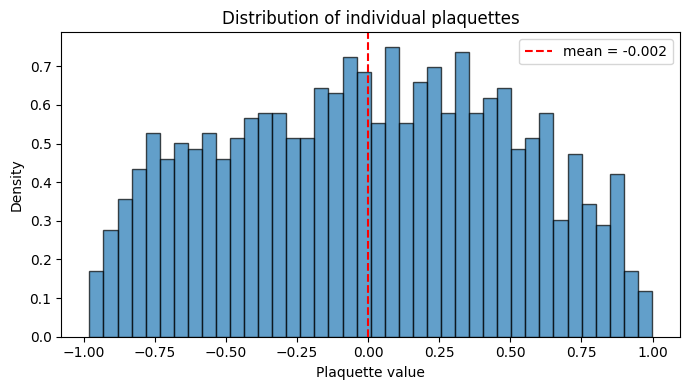

In [8]:
# Collect all plaquette values on the random config
all_plaqs = []
for i in range(V):
    for mu in range(4):
        for nu in range(mu+1, 4):
            p = 0.5 * su2.plaq(U_rand, i, mups, mu, nu)
            all_plaqs.append(p)

all_plaqs = np.array(all_plaqs)
print(f"Total plaquettes measured: {len(all_plaqs)}")
print(f"Mean: {np.mean(all_plaqs):.6f}")
print(f"Std:  {np.std(all_plaqs):.6f}")

plt.figure(figsize=(7, 4))
plt.hist(all_plaqs, bins=40, density=True, alpha=0.7, edgecolor='k')
plt.axvline(np.mean(all_plaqs), color='r', ls='--',
            label=f'mean = {np.mean(all_plaqs):.3f}')
plt.xlabel('Plaquette value')
plt.ylabel('Density')
plt.title('Distribution of individual plaquettes')
plt.legend()
plt.tight_layout()
plt.show()

## Exercises

1. What is the maximum possible value of a single plaquette trace
   $\text{Tr}(W_{\mu\nu})$ for SU(2)? What configuration achieves it?
2. Compute the average plaquette for the identity config.
   Change one link to a random matrix and recompute -- how much does it change?
3. Verify that the staple sum for a cold configuration is exactly
   $6 \times [1,0,0,0]$ at any site.
4. **$\beta$ dependence of the action**: Change $\beta$ from 2.4 to 0.5
   or 10.0 and recompute the action per plaquette for the cold and hot
   starts. Large $\beta$ penalizes disorder heavily; small $\beta$ is
   nearly free. How does $S_g$ change in each case?
5. **Spatial vs temporal plaquettes**: Separate plaquettes into purely
   spatial ($\mu, \nu \in \{0,1,2\}$) and those involving time
   ($\mu$ or $\nu = 3$). On the sample configuration, are their averages
   different? On a thermalized config at finite temperature, temporal
   plaquettes differ from spatial ones — this is a signal of deconfinement.
6. **Staple counting**: For a given link $U_\mu(x)$, how many staples does
   it participate in? In $d$ dimensions, each link has $2(d-1)$ staples
   (forward and backward in each perpendicular direction).
   Verify this is 6 in 4D by checking the staple sum on a cold config.
7. **Action density heatmap**: Compute the local action density
   $s(x) = \sum_{\mu<\nu} (1 - \frac{1}{2}\mathrm{Re\,Tr}\, W_{\mu\nu}(x))$
   at each site of the sample configuration. Plot a 2D slice (e.g., the
   $x$-$y$ plane at $z=0, t=0$) as a heatmap. Where are the "hot spots"?